In [2]:
import sys
import pathlib

# Agregar redes_de_flujo/ al path para importar antenas.py y generar_caso.py
raiz = pathlib.Path('..').resolve()
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

from antenas import obtener_conjunto_backup
from generar_caso import generar_distancias

In [3]:
# Configuración del experimento
K = 2
B = 3
D = 40.0
N_VALORES = [5, 10, 20, 30, 50, 75, 100, 150, 200]
REPETICIONES = 7  # se descartan min y max, se promedian las 5 restantes

tiempos_ms = []

for n in N_VALORES:
    muestras = []
    for rep in range(REPETICIONES):
        dist, _ = generar_distancias(n, seed=42 + rep)
        t0 = time.perf_counter()
        obtener_conjunto_backup(dist, K, B, D)
        t1 = time.perf_counter()
        muestras.append((t1 - t0) * 1000)
    # descartar min y max
    muestras_filtradas = sorted(muestras)[1:-1]
    promedio = sum(muestras_filtradas) / len(muestras_filtradas)
    tiempos_ms.append(promedio)
    print(f"n={n:>3}  tiempo={promedio:.4f} ms")

ns = np.array(N_VALORES, dtype=float)
ts = np.array(tiempos_ms)

n=  5  tiempo=0.0853 ms
n= 10  tiempo=0.3014 ms
n= 20  tiempo=1.4614 ms
n= 30  tiempo=3.8821 ms
n= 50  tiempo=13.6246 ms
n= 75  tiempo=40.6990 ms
n=100  tiempo=91.4605 ms
n=150  tiempo=313.5253 ms
n=200  tiempo=781.0725 ms


Constante ajustada: C = 9.684894e-05  →  f(n) = 9.685e-05 · n³
Gráfico guardado en: C:\Users\Joaquin H\repos\tda_echeverria_tp2\informe\img\grafico_tiempos.png


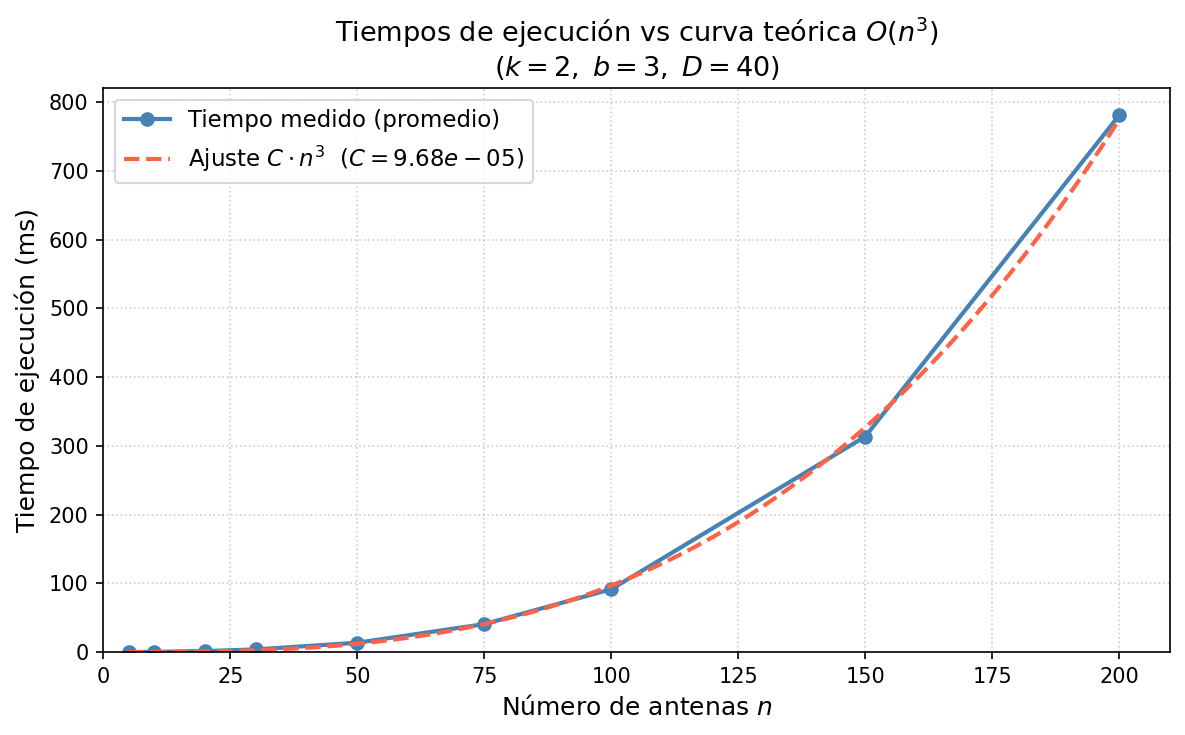

In [4]:
# Ajuste de curva f(n) = C * n^3 (mínimos cuadrados sin término independiente)
A = (ns ** 3).reshape(-1, 1)
C, _, _, _ = np.linalg.lstsq(A, ts, rcond=None)
C = C[0]
print(f"Constante ajustada: C = {C:.6e}  →  f(n) = {C:.3e} · n³")

n_fino = np.linspace(ns[0], ns[-1], 400)
t_teorico = C * n_fino ** 3

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ns, ts, 'o-', color='steelblue', linewidth=2, markersize=6, label='Tiempo medido (promedio)')
ax.plot(n_fino, t_teorico, '--', color='tomato', linewidth=2, label=f'Ajuste $C\\cdot n^3$  ($C={C:.2e}$)')

ax.set_xlabel('Número de antenas $n$', fontsize=12)
ax.set_ylabel('Tiempo de ejecución (ms)', fontsize=12)
ax.set_title('Tiempos de ejecución vs curva teórica $O(n^3)$\n($k=2,\\; b=3,\\; D=40$)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(0, ns[-1] * 1.05)
ax.set_ylim(bottom=0)

plt.tight_layout()

salida = pathlib.Path('../../informe/img/grafico_tiempos.png')
salida.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(salida, dpi=150, bbox_inches='tight')
print(f"Gráfico guardado en: {salida.resolve()}")
plt.show()